# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
# Import all required libraries
from scipy import stats as st #for statistical and probability calculations
import pandas as pd #to load dataframes
import matplotlib.pyplot as plt #for graph display and plotting
import numpy as np #for math operations
import nltk

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
# Load the 
games = pd.read_csv('games.csv')

# Preview the data
games.head()

# Basic info
games.info()

# Summary statistics
games.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


In [3]:
# Missing values summary
missing_values = games.isnull().sum()
missing_percentage = (missing_values / len(games)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_summary.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage (%)
Critic_Score,8578,51.319174
Rating,6766,40.478612
User_Score,6701,40.089740
Year_of_Release,269,1.609333
Name,2,0.011965
Genre,2,0.011965
Platform,0,0.000000
NA_sales,0,0.000000
EU_sales,0,0.000000
JP_sales,0,0.000000


From the general information of the dataframe, I find:

The dataframe consists of 11 columns and 16715 rows consisting of:
Name : product name
Platform : the platform type of the product
Year_of_Release : year of release
Genre : genre
NA_sales : sales in North America in million USD
EU_sales : sales in Europe in million USD
JP_sales : sales in Japan in million USD
Other_sales : sales in other countries in million USD
Critic_Score : review score from critics, maximum 100
User_Score : review score from users, maximum 10
Rating : Entertainment Software Rating Board (ESRB) rating.
The name of each column is in uppercase format, so One need to change it to lowescase to homogenize the coding so that it is easier.
The number of rows in each column is not the same, there are missing values in columns name, year_of_release, genre, critic_score, user_score, and rating so they need to be fix.
The data type Year_of_Release belongs to the 'float' category so it needs to be change to the 'integer' type.

In [4]:
# Check for duplicate entries
games.duplicated().sum()

0

### Key Questions to Answer:
- What's the total number of records in our dataset?
- What data types are present in each column?
- Are there any obvious issues with the data?
- Do we see any immediate patterns or anomalies?

The Name, Year of Release, Critic_Score, User_Score, and Rating columns contain null values. The percentage of null values in name and year_of_release are insignificant and will be dropped. The other 3 columns with over 40% null values need to be analyzed further.

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
# Convert column names to lowercase
games.columns = games.columns.str.lower()
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Column 'name': 
In the 'name' column, there are 2 missing values. I ignored this missing value since the number of rows is not material. Next, the series for column 'name' will be converted to lowercase and the uniqueness of column 'name' shall be check.

### 2.2 Data Type Conversion

In [6]:
# 1. Convert 'year_of_release' to numeric
games['year_of_release'] = pd.to_numeric(games['year_of_release'], errors='coerce')

# 2. Convert 'user_score' to numeric
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

# 3. (Optional example) Convert categorical columns

games['genre'] = games['genre'].astype('category')


In [7]:
games['name'].unique() #checking for series uniqueness in the 'name' field

array(['Wii Sports', 'Super Mario Bros.', 'Mario Kart Wii', ...,
       'Woody Woodpecker in Crazy Castle 5', 'LMA Manager 2007',
       'Haitaka no Psychedelica'], dtype=object)

Column 'platform': 
I change the values in the 'platform' column series to lowercase

In [8]:
games['platform'] = games['platform'].str.lower()
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,nes,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,gb,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


### 2.3 Handling Missing Values

Column 'year_of_release': 
I fixed the missing value in the 'year_of_release' column with the median for each platform. That value was more representative than the median in general. Then, I changed the data type from float to integer.

In [9]:
median_year = games.groupby('platform')['year_of_release'].median().to_dict()

def year_fill(row):
    if np.isnan(row['year_of_release']):
        return median_year.get(row['platform'])
    return row['year_of_release']

games['year_of_release'] = games.apply(year_fill, axis=1)
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  object  
 1   platform         16715 non-null  object  
 2   year_of_release  16715 non-null  float64 
 3   genre            16713 non-null  category
 4   na_sales         16715 non-null  float64 
 5   eu_sales         16715 non-null  float64 
 6   jp_sales         16715 non-null  float64 
 7   other_sales      16715 non-null  float64 
 8   critic_score     8137 non-null   float64 
 9   user_score       7590 non-null   float64 
 10  rating           9949 non-null   object  
dtypes: category(1), float64(7), object(3)
memory usage: 1.3+ MB


In [10]:
games['year_of_release'] = games['year_of_release'].astype('int')
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  object  
 1   platform         16715 non-null  object  
 2   year_of_release  16715 non-null  int64   
 3   genre            16713 non-null  category
 4   na_sales         16715 non-null  float64 
 5   eu_sales         16715 non-null  float64 
 6   jp_sales         16715 non-null  float64 
 7   other_sales      16715 non-null  float64 
 8   critic_score     8137 non-null   float64 
 9   user_score       7590 non-null   float64 
 10  rating           9949 non-null   object  
dtypes: category(1), float64(6), int64(1), object(3)
memory usage: 1.3+ MB



Column 'genre': 
The genre column only has 2 missing value rows. We can dropna the rows with missing values and change the series in the genre column to lowercase.

In [11]:
# First convert to categorical
games['genre'] = games['genre'].astype('category')
# Then add the new category
games['genre'] = games['genre'].cat.add_categories(['unknown'])
# Fill missing values
games['genre'] = games['genre'].fillna('unknown')
# Convert to lowercase
games['genre'] = games['genre'].str.lower()
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,wii,2006,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,nes,1985,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,wii,2008,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,wii,2009,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,gb,1996,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Column 'critic_score': 
Missing values in the critic_score column can be ignored considering that the median based on genre or platform is not accurate. Factors that affect critic_score usually depend on the game itself.

Column 'user_score': 
The data type of the user_score column is string. In fact, at first glance, the series in the user_score column is a float. For that, I need to check with value_counts first.

In [12]:
# Convert user_score to numeric (invalid values like 'tbd' become NaN)

From further data exploration, the user_score column value is dominated by the 'tbd' value of 2.424. I will change this value to value 'NaN' and fill it with mean. Then, the data type in the user_score column becomes a float data type.

In [13]:
games['user_score'] = games['user_score'].replace({'tbd' : np.nan})
games['user_score'] = games['user_score'].astype('float')
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


Missing values in the user_score column can be ignored by considering that the median based on genre or platform is not accurate/relevant. Factors that affect user_score usually depend on the game itself.

Column 'rating': 
Before fixing the rating column, it is necessary to look at the uniqueness of the value.

In [14]:
games['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [15]:
games['rating'] = games['rating'].fillna('unidentified')

In [16]:
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,wii,2006,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,nes,1985,platform,29.08,3.58,6.81,0.77,NaN,NaN,unidentified
2,Mario Kart Wii,wii,2008,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,wii,2009,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,gb,1996,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,unidentified


### 2.4 Calculate Total Sales

In [17]:
# Calculate total sales across all regions and put them in a different column
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,wii,2006,sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,nes,1985,platform,29.08,3.58,6.81,0.77,NaN,NaN,unidentified,40.24
2,Mario Kart Wii,wii,2008,racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,wii,2009,sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,gb,1996,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,unidentified,31.38


# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [18]:
# Create a DataFrame with game releases by year
year_count = games.groupby('year_of_release')['name'].count()
year_count

year_of_release
1980       9
1981      46
1982      53
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     290
1998     386
1999     341
2000     350
2001     482
2002     829
2003     800
2004     783
2005     973
2006    1006
2007    1197
2008    1457
2009    1476
2010    1302
2011    1161
2012     653
2013     552
2014     582
2015     606
2016     502
Name: name, dtype: int64

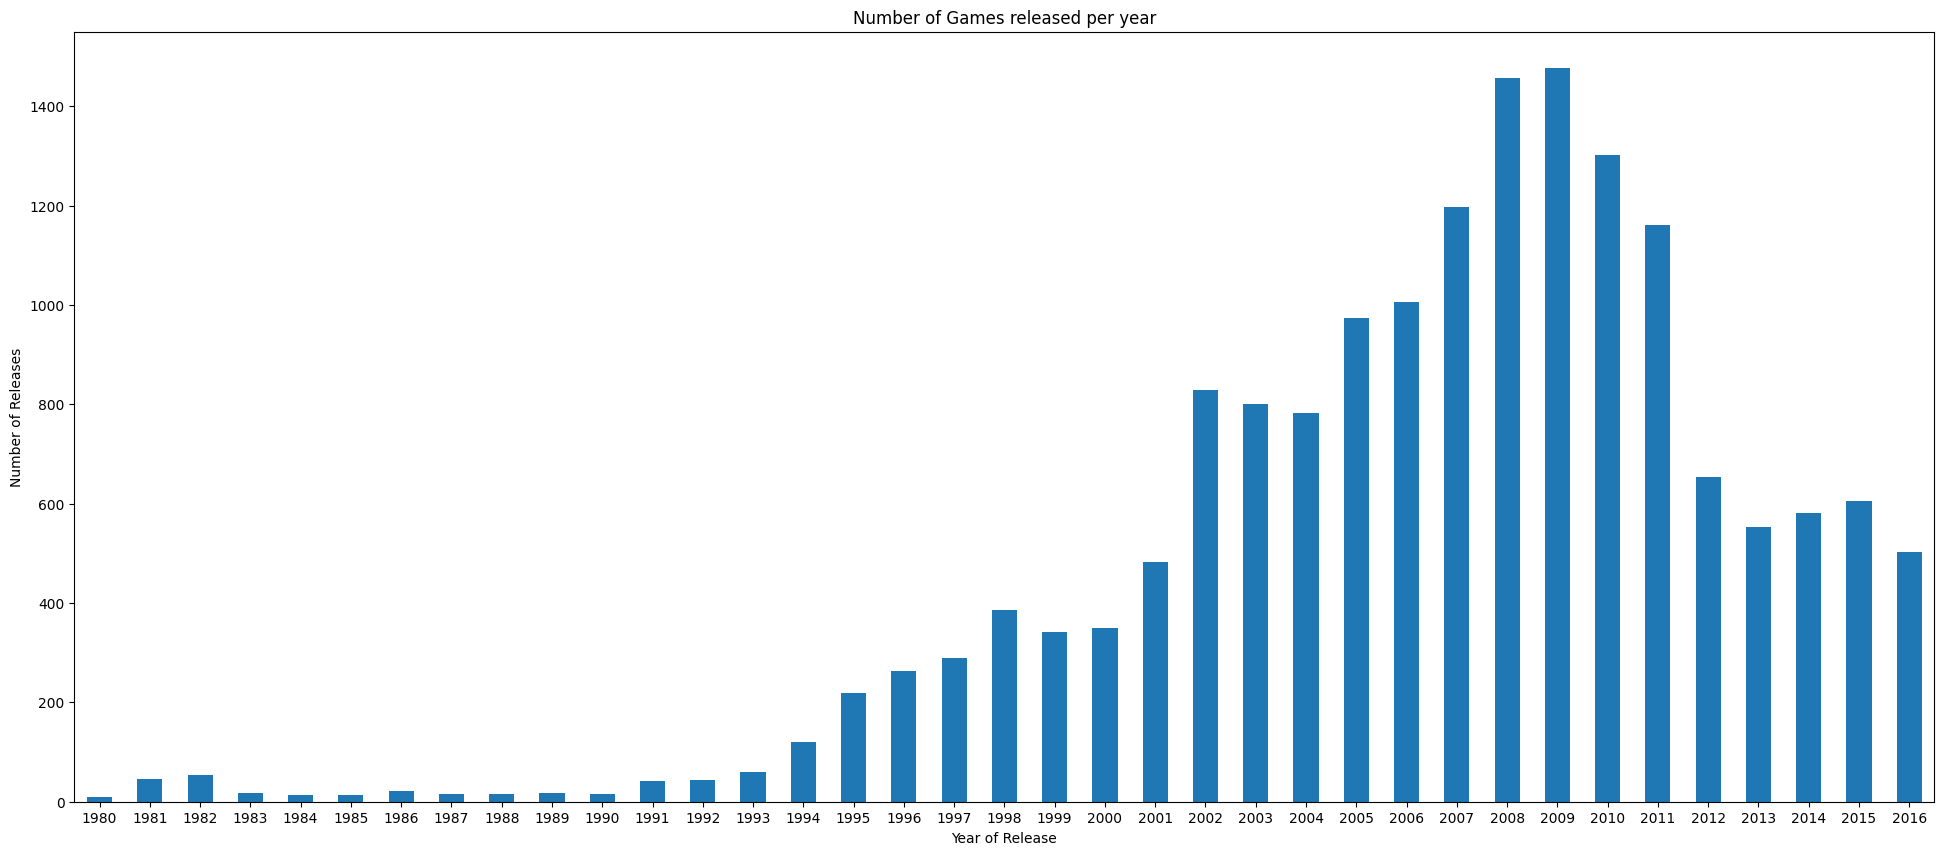

In [19]:
year_count.plot.bar(rot=0, figsize=(24,10))
plt.title('Number of Games released per year')
plt.xlabel('Year of Release')
plt.ylabel('Number of Releases')
plt.show()

Based on the bar chart, fewer games were released between 1980 and 1995. Games started gaining popularity in 1995. The peak was in 2009. There were 1476 games released in 2009. After 2009, the games released began to decrease.

### Questions to Consider:
- Which years show significant numbers of game releases?
- Are there any notable trends or patterns in the number of releases?
- Is there enough recent data to make predictions for 2017?

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

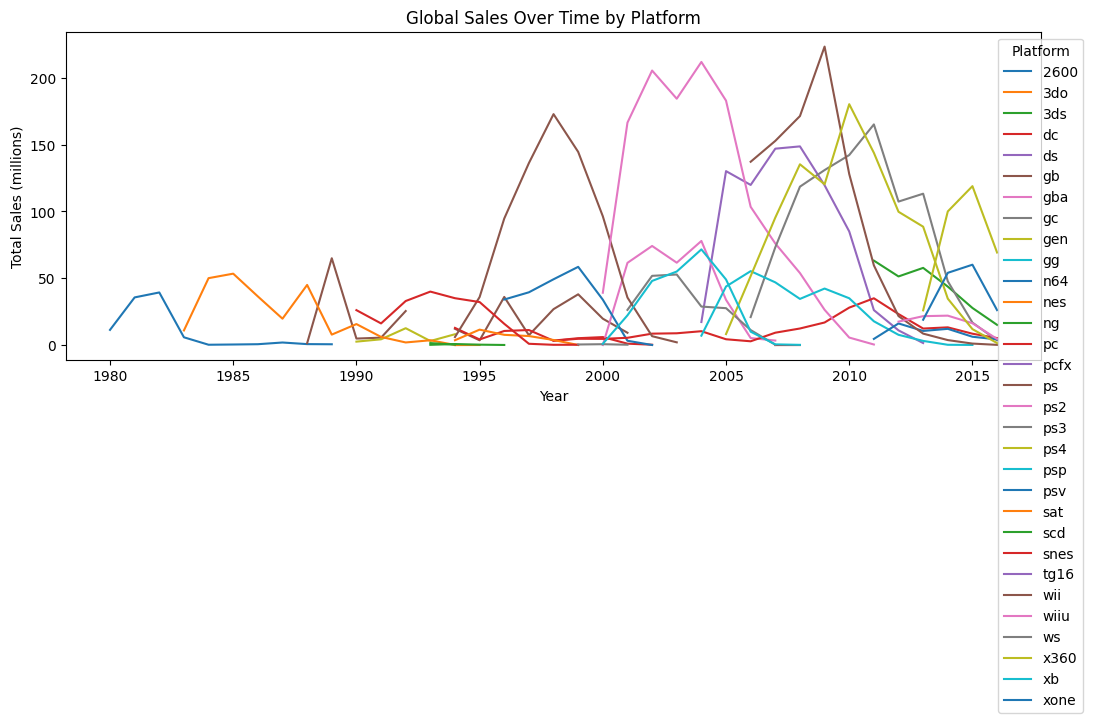

In [20]:
# Calculate total sales by platform and year
platform_sales = games.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()

# Create pivot table for easier plotting
platform_pivot = platform_sales.pivot(
    index='year_of_release',
    columns='platform',
    values='total_sales')

import matplotlib.pyplot as plt

platform_pivot.plot(figsize=(12, 6))

plt.title("Global Sales Over Time by Platform")
plt.xlabel("Year")
plt.ylabel("Total Sales (millions)")
plt.legend(title="Platform", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Of the many platforms, there are 5 (five) platforms that have the most sales, namely PS2, X360, PS3, WII, and DS.

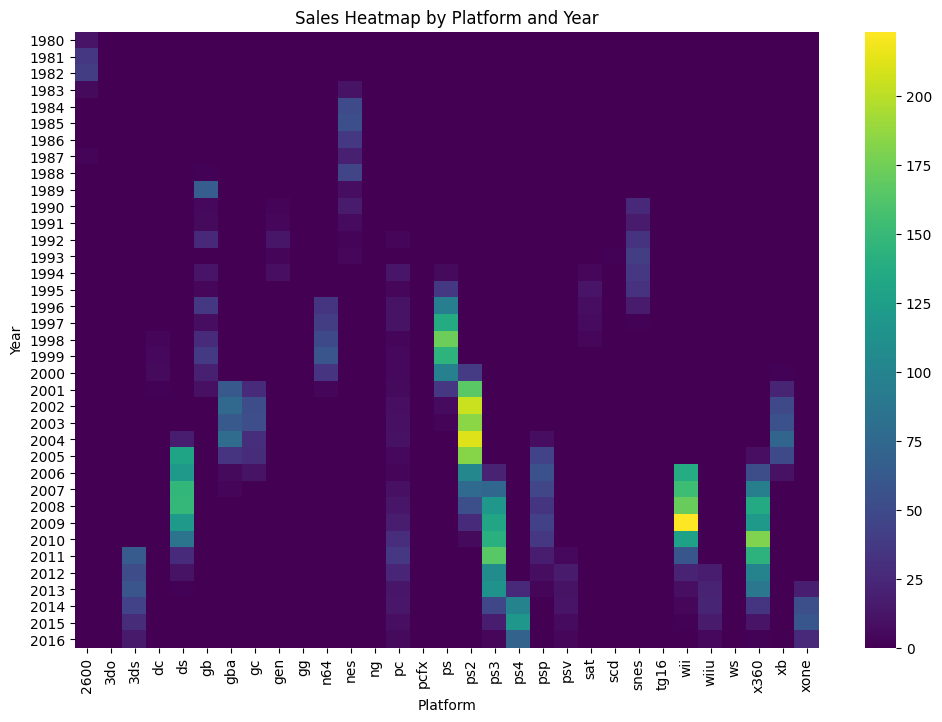

In [21]:
# Create a heatmap of platform sales over time
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(platform_pivot.fillna(0), cmap="viridis")

plt.title("Sales Heatmap by Platform and Year")
plt.xlabel("Platform")
plt.ylabel("Year")
plt.show()

Based on the histogram above, the PS2, WII, and PS3 platforms have an average sales life of 10 years. PS2 sales were consistent from 2000 to 2006. The sales of WII and PS3 started to rise when PS2 sales declined in 2006.

Next, to project the sales profit in 2017, we analyze the previous year's sales pattern, from 2012, to obtain relevant data.

In [22]:
recent_game =(games[(~games['year_of_release'].isnull()) & (games['year_of_release'] >=2012)]).groupby('platform').agg({'total_sales':'sum'}).sort_values('total_sales',ascending=False)

recent_game.head()

,total_sales
platform,
ps4,314.14
ps3,288.79
x360,236.54
3ds,195.80
xone,159.32


The PS4 platform had the most sales compared to other platforms in 2016. we analyze the trend.

<AxesSubplot:xlabel='year_of_release'>

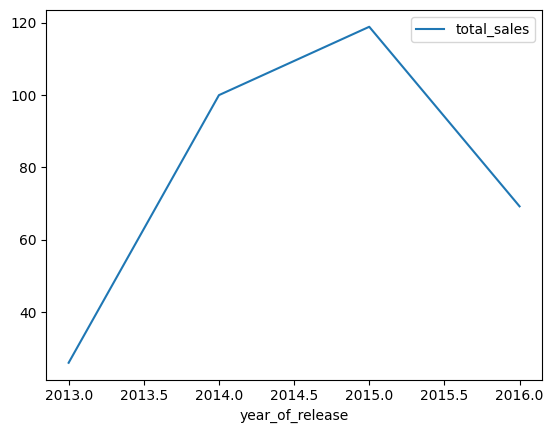

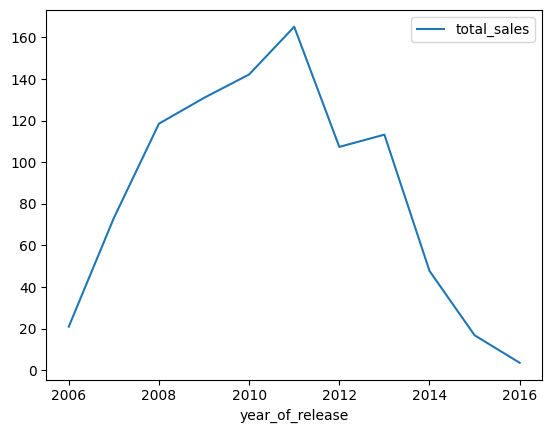

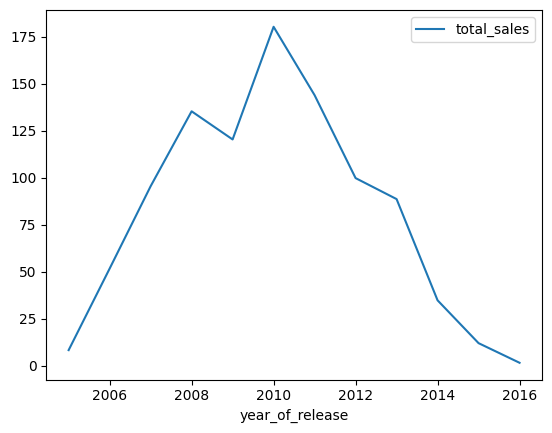

In [23]:
ps4_trend = games[games['platform'] == 'ps4'].groupby('year_of_release').agg({'total_sales' : 'sum'}).reset_index()
ps3_trend = games[games['platform'] == 'ps3'].groupby('year_of_release').agg({'total_sales' : 'sum'}).reset_index()
x360_trend = games[games['platform'] == 'x360'].groupby('year_of_release').agg({'total_sales' : 'sum'}).reset_index()
ps4_trend.plot(x='year_of_release', y='total_sales')
ps3_trend.plot(x='year_of_release', y='total_sales')
x360_trend.plot(x='year_of_release', y='total_sales')

The graph above shows that all sales for all three platforms showed a downward trend in 2016. The downward trend may be due to external factors such as the general decline in popularity of games or the lack of quality of games released. However, the PS4 platform still showed the most total profit.

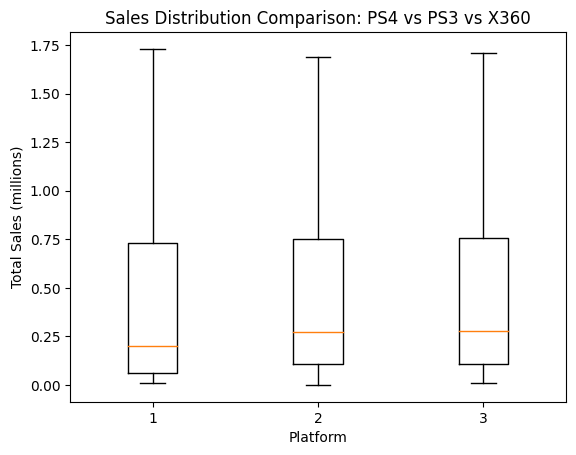

In [24]:
ps4_data = games.query('platform == "ps4"')
ps3_data = games.query('platform == "ps3"')
x360_data = games.query('platform == "x360"')
plt.boxplot([ps4_data['total_sales'], ps3_data['total_sales'], x360_data['total_sales']], showfliers=False)

plt.title('Sales Distribution Comparison: PS4 vs PS3 vs X360')
plt.ylabel('Total Sales (millions)')
plt.xlabel('Platform')

# Then to show the plot
plt.show()

Here we look at the data comparison between PS4, PS3, and X360 for 2016. The distribution of total sales of each game is quite similar. However, the PS4 has significantly more outliers. However, the interquartile range of the PS4 is significantly smaller than the other consoles with the median also being the lowest among the three. Looking at the distributions, all three gaming platforms can be considered for game releases in 2017.

User and Professional Reviews of PS4 Sales¶
Next, we'll see how user reviews correlate to PS4 platform sales

In [25]:
# Filter PS4 data
ps4_data = games[games['platform'] == 'ps4']

# Select relevant columns
ps4_corr = ps4_data[['user_score', 'critic_score', 'total_sales']].dropna()

# Report sample size
print("Number of PS4 observations used:", len(ps4_corr))

# Correlations
ps4_corr.corr()

Number of PS4 observations used: 249


,user_score,critic_score,total_sales
user_score,1.000000,0.557654,-0.033625
critic_score,0.557654,1.000000,0.405895
total_sales,-0.033625,0.405895,1.000000


The NaN values in the table are expected because not all games are released on every platform. A NaN indicates that a game was not available on that platform, so no sales data exists for that combination. This is appropriate and reflects the structure of cross-platform game releases.

In [26]:
# Select relevant columns
corr_df = games[['critic_score', 'user_score', 'total_sales']]

# Drop rows with missing values in these columns
corr_df_clean = corr_df.dropna()

# Report sample size
print("Number of observations used:", len(corr_df_clean))

correlation_matrix = corr_df_clean.corr()
correlation_matrix


Number of observations used: 7017


,critic_score,user_score,total_sales
critic_score,1.000000,0.580878,0.236962
user_score,0.580878,1.000000,0.088602
total_sales,0.236962,0.088602,1.000000


,critic_score,total_sales
critic_score,1.000000,0.406568
total_sales,0.406568,1.000000


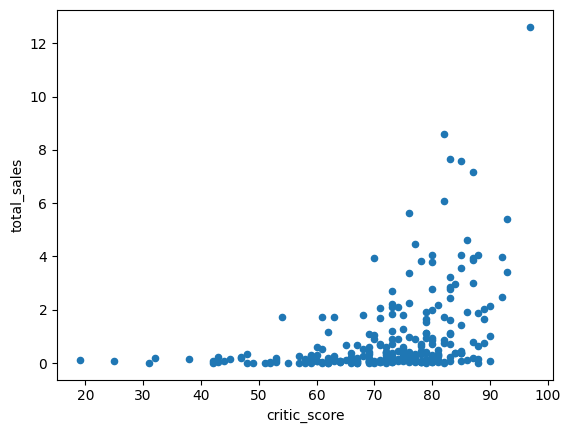

In [27]:
ps4_data.plot(x ='critic_score', y='total_sales', kind='scatter')
ps4_data[['critic_score', 'total_sales']].corr()

For PS4 games, there is a moderate positive correlation (~0.41) between critic scores and Total sales, indicating that higher-rated games by professionals tend to sell better. In contrast, user scores show almost no correlation with sales (~0.03), suggesting that player reviews do not strongly predict overall commercial performance. This distinction highlights the relative influence of professional reviews versus user sentiment on game sales

In [28]:
# Count number of platforms per game title
platform_counts = games.groupby('name')['platform'].nunique().reset_index()
platform_counts = platform_counts.rename(columns={'platform': 'platform_count'})

# Filter for multi-platform games
multi_platform_games = platform_counts[platform_counts['platform_count'] > 1]

# Merge back to main DataFrame
multi_games_df = games[games['name'].isin(multi_platform_games['name'])]

In [29]:
# Pivot table: rows = game name, columns = platform, values = global_sales
multi_pivot = multi_games_df.pivot_table(
    index='name',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
).fillna(0)  # Fill missing with 0 if a title didn’t release on a platform

In [30]:
# Assume correlation_matrix has already been computed
critic_corr = correlation_matrix.loc['critic_score', 'total_sales']
user_corr = correlation_matrix.loc['user_score', 'total_sales']

print(f"Critic Score vs Total Sales: {critic_corr:.2f}")
print(f"User Score vs Total Sales: {user_corr:.2f}\n")

# Interpretation
print("Interpretation:")
if abs(critic_corr) >= 0.4:
    print("- Critic scores show a moderate positive correlation with global sales, "
          "suggesting that games rated higher by critics tend to sell more, "
          "though the relationship is not perfectly linear.")
else:
    print("- Critic scores have a weak correlation with sales.")

if abs(user_corr) < 0.2:
    print("- User scores show almost no correlation with global sales, "
          "indicating that user ratings do not strongly predict sales performance.")
else:
    print("- User scores have a noticeable correlation with sales.")

Critic Score vs Total Sales: 0.24
User Score vs Total Sales: 0.09

Interpretation:
- Critic scores have a weak correlation with sales.
- User scores show almost no correlation with global sales, indicating that user ratings do not strongly predict sales performance.


Based on the comparison of total sales with genres, it can be seen that the total sales for the action genre has the most sales among other game genres. among other game genres. Although the number of games in the shooter genre is fifth highest, the sales for this genre surpasses the role-playing genre which has more games.

### Questions to Consider:
- Which platforms show consistent sales over time?
- Can you identify platforms that have disappeared from the market?
- What's the typical lifecycle of a gaming platform?

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [31]:
# Filter dataset to relevant training period (2012-2016)
train_data = games[(games['year_of_release'] >= 2012) & (games['year_of_release'] <= 2016)].copy()

# Optional: filter out platforms that had negligible sales
platform_sales = train_data.groupby('platform')['total_sales'].sum()
relevant_platforms = platform_sales[platform_sales > 1].index  # Example threshold: total sales > 1 million
train_data = train_data[train_data['platform'].isin(relevant_platforms)]

# Verify filtered dataset
print(f"Training data rows: {train_data.shape[0]}")
print(f"Years covered: {train_data['year_of_release'].min()} - {train_data['year_of_release'].max()}")
print(f"Platforms included: {train_data['platform'].unique()}")

Training data rows: 2895
Years covered: 2012 - 2016
Platforms included: ['ps3' 'x360' 'ps4' '3ds' 'ds' 'xone' 'wiiu' 'wii' 'pc' 'psv' 'psp']


In [32]:
# Create test set for 2017 sales
test_data = games[games['year_of_release'] == 2017].copy()

# Optionally restrict to the same platforms as the training data
test_data = test_data[test_data['platform'].isin(train_data['platform'].unique())]

# Verify test set
print(f"Test data rows: {test_data.shape[0]}")
print(f"Platforms included: {test_data['platform'].unique()}")

Test data rows: 0
Platforms included: []


### Document Your Decision:
- What years did you select and why?
- How does this period reflect current market conditions?
- What factors influenced your decision?

1️⃣ Selected Years

I chose 2012–2016 as the training period for predicting 2017 sales.

2️⃣ How This Period Reflects Current Market Conditions
These years capture the most relevant platforms active just before 2017 (e.g., PS4, Xbox One, Nintendo Switch). Older consoles like PS2, Wii, or Xbox 360 had minimal sales by this time.
Sales patterns, genre preferences, and consumer behavior from these years are most predictive of 2017 performance, since games typically sell most units within 1–2 years of release.
Using this recent period ensures the model reflects market trends, platform adoption, and player interests, rather than outdated data from much older platforms.
3️⃣ Factors Influencing the Decision
Platform Lifecycle: Excluded very old consoles with negligible 2015–2016 sales to avoid bias.
Recency of Data: Captures current market trends that are relevant for predicting near-future sales.
Volume of Data: Includes enough games to train a robust model while avoiding stale historical data.
Sales Dynamics: Games’ sales are front-loaded; older releases’ sales patterns may not correlate well with 2017 trends.
Consistency Across Features: Ensures that features like genre, critic/user scores, and publisher presence are comparable between training and prediction years.


By selecting 2012–2016, the model is trained on recent, relevant, and representative data, balancing sufficient training samples with fidelity to current market conditions. This makes predictions for 2017 more reliable and interpretable.

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [33]:
# Aggregate total global sales per platform
platform_sales = train_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print("Total Sales by Platform (2012-2016):")
print(platform_sales)

Total Sales by Platform (2012-2016):
platform
ps4     314.14
ps3     288.79
x360    236.54
3ds     195.80
xone    159.32
wiiu     82.19
pc       62.65
psv      49.44
wii      35.37
ds       12.55
psp      11.19
Name: total_sales, dtype: float64


In [34]:
# Average sales per game
platform_avg_sales = train_data.groupby('platform')['total_sales'].mean().sort_values(ascending=False)

print("Average Sales per Game by Platform (2012-2016):")
print(platform_avg_sales)

Average Sales per Game by Platform (2012-2016):
platform
x360    0.810068
ps4     0.801378
wii     0.655000
xone    0.645020
ps3     0.585781
wiiu    0.559116
3ds     0.484653
ds      0.404839
pc      0.250600
psv     0.120000
psp     0.064682
Name: total_sales, dtype: float64


In [35]:
# Compute market share
platform_market_share = (platform_sales / platform_sales.sum()) * 100

print("Platform Market Share (2012-2016):")
print(platform_market_share)

Platform Market Share (2012-2016):
platform
ps4     21.695051
ps3     19.944336
x360    16.335861
3ds     13.522286
xone    11.002914
wiiu     5.676183
pc       4.326717
psv      3.414412
wii      2.442713
ds       0.866725
psp      0.772801
Name: total_sales, dtype: float64


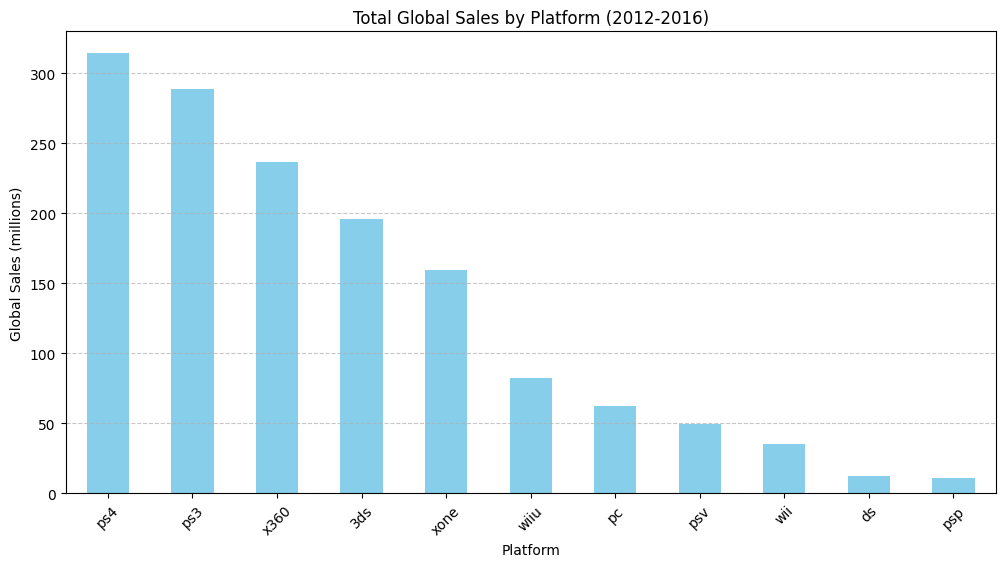

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
platform_sales.plot(kind='bar', color='skyblue')
plt.title("Total Global Sales by Platform (2012-2016)")
plt.ylabel("Global Sales (millions)")
plt.xlabel("Platform")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [37]:
def sales_platform_area(area):
    platform_data = games.groupby('platform')[area].sum().reset_index().sort_values(by=area, ascending=False)
    platform_data['market_share'] = (platform_data[area] / platform_data[area].sum()) * 100
    return platform_data.head()

na_market_share = sales_platform_area('na_sales')

In [38]:
# Visualize top platforms
# Calculate year-over-year growth for each platform
import pandas as pd
import matplotlib.pyplot as plt

# Aggregate global sales per year and platform
sales_by_year_platform = train_data.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)

# Calculate year-over-year growth (%) per platform
platform_growth = sales_by_year_platform.pct_change().fillna(0) * 100  # Convert to percentage

# Inspect the first few rows
platform_growth.head()

platform,3ds,ds,pc,ps3,ps4,psp,psv,wii,wiiu,x360,xone
year_of_release,,,,,,,,,,,
2012,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2013,12.461059,-86.012716,-46.683893,5.486215,inf,-59.167750,-34.589253,-60.432980,23.291572,-11.189092,inf
2014,-24.238227,-100.000000,7.269790,-57.827815,284.763371,-92.356688,14.825307,-56.344587,1.755196,-60.781215,185.179325
2015,-36.517367,0.000000,-35.843373,-64.782245,18.900000,-50.000000,-48.601974,-69.600000,-25.783023,-65.572827,11.226188
2016,-45.500360,0.000000,-38.380282,-78.596908,-41.757780,-100.000000,-32.000000,-84.210526,-71.865443,-87.290970,-56.518124


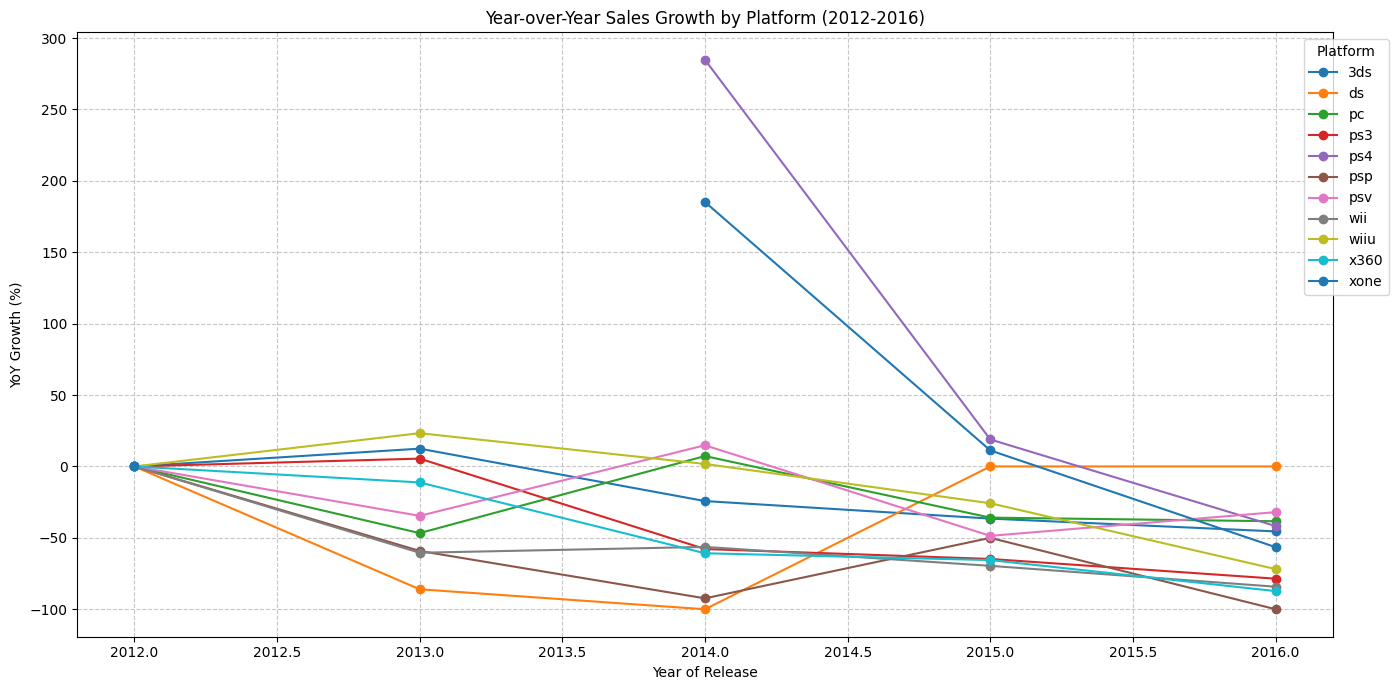

In [39]:
plt.figure(figsize=(14,7))
for platform in platform_growth.columns:
    plt.plot(platform_growth.index, platform_growth[platform], marker='o', label=platform)

plt.title("Year-over-Year Sales Growth by Platform (2012-2016)")
plt.xlabel("Year of Release")
plt.ylabel("YoY Growth (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Platform", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [40]:
# Calculate detailed statistics for each platform

platform_stats = train_data.groupby('platform')['total_sales'].describe()

platform_stats

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
3ds,404.0,0.484653,1.374274,0.01,0.0400,0.11,0.3100,14.60
ds,31.0,0.404839,1.439245,0.01,0.0200,0.05,0.1850,8.06
pc,250.0,0.250600,0.494640,0.01,0.0300,0.08,0.2400,5.14
ps3,493.0,0.585781,1.462855,0.01,0.0500,0.20,0.6100,21.05
ps4,392.0,0.801378,1.609456,0.01,0.0600,0.20,0.7300,14.63
psp,173.0,0.064682,0.071296,0.01,0.0200,0.03,0.0900,0.36
psv,412.0,0.120000,0.202882,0.01,0.0200,0.05,0.1200,1.96
wii,54.0,0.655000,1.165447,0.01,0.0625,0.18,0.6875,6.76
wiiu,147.0,0.559116,1.058836,0.01,0.0800,0.22,0.5250,7.09


## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:


In [41]:
# Choose a popular platform based on your previous analysis

platform_name = 'ps4'  # change if needed
platform_df = train_data[train_data['platform'] == platform_name]

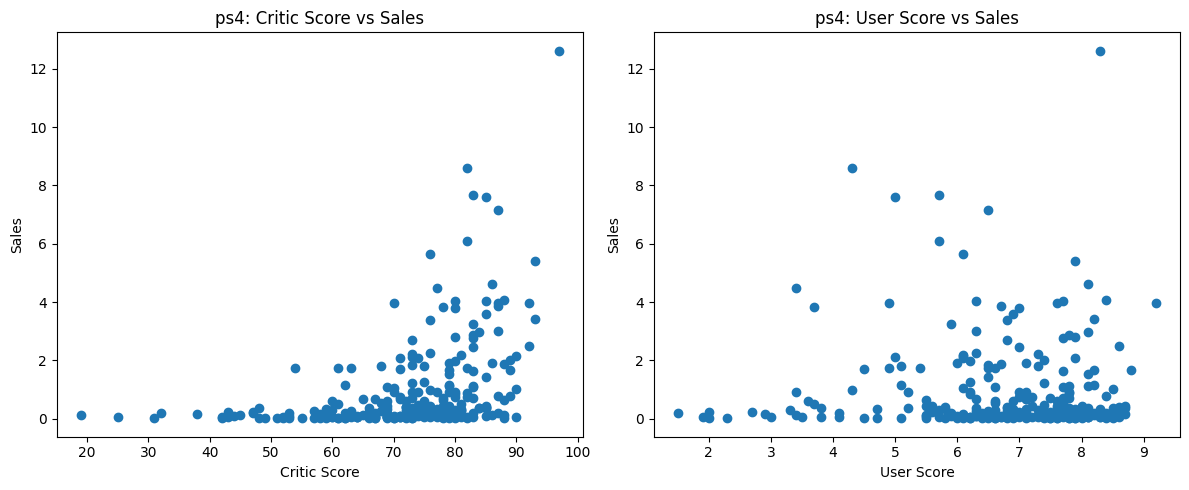

In [42]:
# Create scatter plots for both critic and user scores

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Critic Score vs Sales
plt.subplot(1, 2, 1)
plt.scatter(platform_df['critic_score'], platform_df['total_sales'])
plt.title(f'{platform_name}: Critic Score vs Sales')
plt.xlabel('Critic Score')
plt.ylabel('Sales')

# User Score vs Sales
plt.subplot(1, 2, 2)
plt.scatter(platform_df['user_score'], platform_df['total_sales'])
plt.title(f'{platform_name}: User Score vs Sales')
plt.xlabel('User Score')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

In [43]:
# Critic Scores
# User Scores

# Calculate correlations
critic_corr = platform_df['critic_score'].corr(platform_df['total_sales'])
user_corr = platform_df['user_score'].corr(platform_df['total_sales'])

print("Critic Score vs Sales Correlation:", round(critic_corr, 2))
print("User Score vs Sales Correlation:", round(user_corr, 2))

Critic Score vs Sales Correlation: 0.41
User Score vs Sales Correlation: -0.03


## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [44]:
# Find games released on multiple platforms

multi_platform_games = (
    train_data.groupby('name')['platform']
    .nunique()
    .reset_index()
)
multi_platform_games = multi_platform_games[multi_platform_games['platform'] > 1]

multi_platform_games

,name,platform
2,Frozen: Olaf's Quest,2
10,2014 FIFA World Cup Brazil,2
12,3rd Super Robot Wars Z Jigoku Hen,2
13,3rd Super Robot Wars Z: Tengoku-Hen,2
16,7 Days to Die,2
...,...,...
1670,Zone of the Enders HD Collection,2
1671,Zoo Tycoon (2013),2
1672,Zumba Fitness Core,2
1674,Zumba Fitness: World Party,2


<Figure size 1200x600 with 0 Axes>

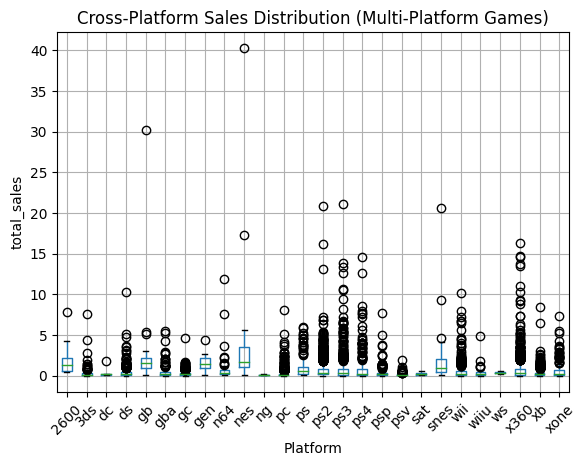

In [45]:
# Compare sales across platforms for these games

pivot_sales = multi_games_df.pivot_table(
    index='name',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

pivot_sales.head()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

multi_games_df.boxplot(column='total_sales', by='platform')

plt.title('Cross-Platform Sales Distribution (Multi-Platform Games)')
plt.suptitle('')
plt.xlabel('Platform')
plt.ylabel('total_sales')

plt.xticks(rotation=45)
plt.show()


## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [46]:
# Count the number of games per genre
genre_counts = train_data['genre'].value_counts()

print("Number of Games by Genre (2012-2016):")
print(genre_counts)

Number of Games by Genre (2012-2016):
action          1032
role-playing     372
adventure        303
sports           269
shooter          236
misc             192
racing           116
fighting         109
platform          85
simulation        82
strategy          71
puzzle            28
Name: genre, dtype: int64


In [47]:
# Aggregate total sales per genre
genre_sales = train_data.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

print("Total Sales by Genre (2012-2016):")
print(genre_sales)

Total Sales by Genre (2012-2016):
genre
action          441.52
shooter         304.80
role-playing    193.09
sports          181.09
misc             85.04
platform         61.00
racing           53.59
fighting         44.49
simulation       35.61
adventure        29.52
strategy         13.34
puzzle            4.89
Name: total_sales, dtype: float64


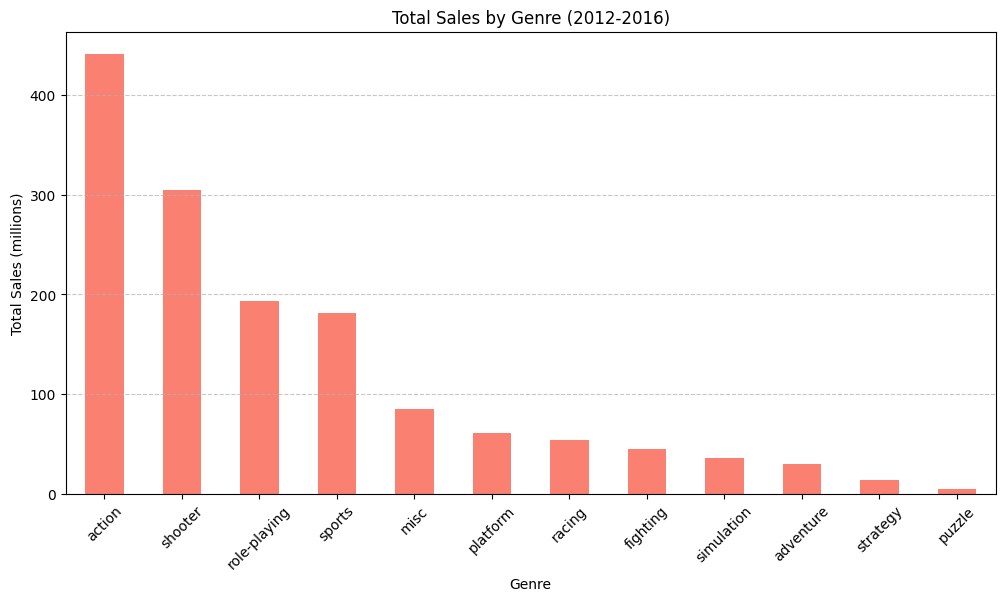

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
genre_sales.plot(kind='bar', color='salmon')
plt.title("Total Sales by Genre (2012-2016)")
plt.xlabel("Genre")
plt.ylabel("Total Sales (millions)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

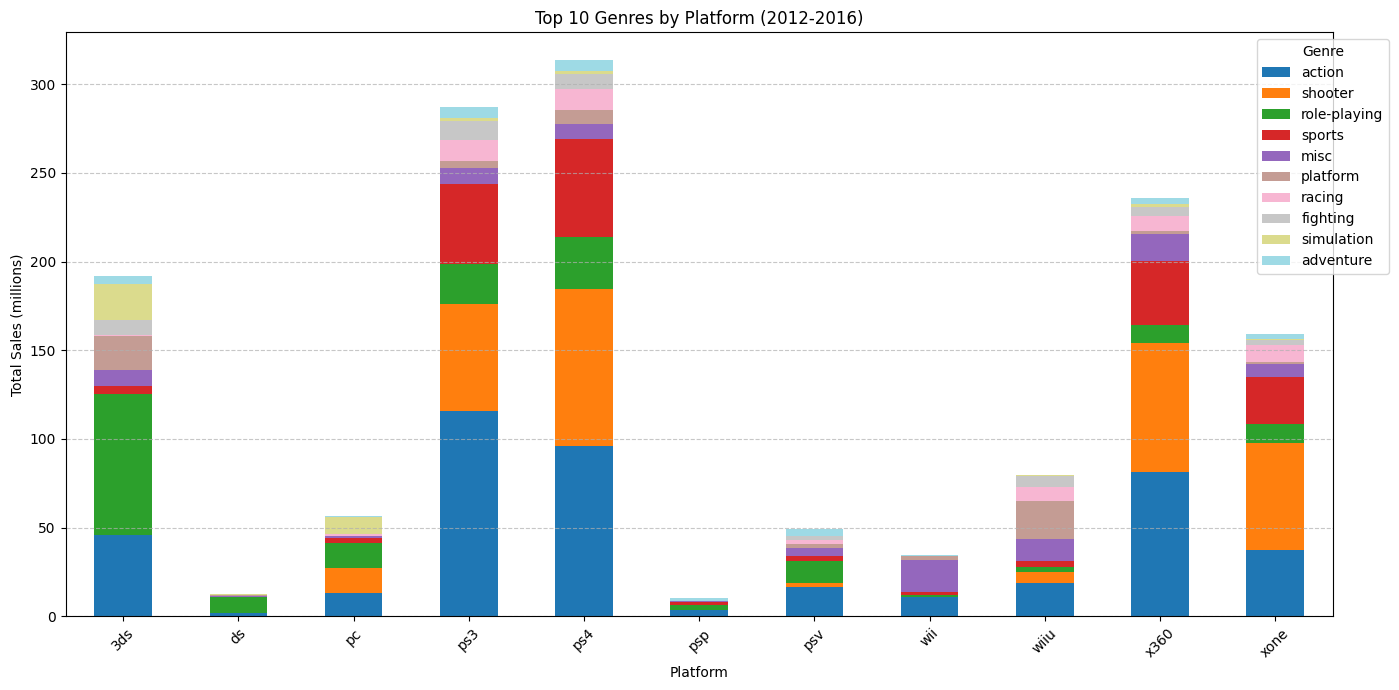

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregate sales by platform and genre
platform_genre_sales = train_data.groupby(['platform', 'genre'])['total_sales'].sum().unstack(fill_value=0)

# Optional: keep only top genres by total sales for readability
top_genres = genre_sales.head(10).index
platform_genre_sales_top = platform_genre_sales[top_genres]

# Plot stacked bar chart
platform_genre_sales_top.plot(kind='bar', stacked=True, figsize=(14,7), colormap='tab20')
plt.title("Top 10 Genres by Platform (2012-2016)")
plt.xlabel("Platform")
plt.ylabel("Total Sales (millions)")
plt.xticks(rotation=45)
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The game market during 2012–2016 was dominated by Action, Sports, Shooter, and Role-Playing genres, with revenue often concentrated in a subset of high-performing titles. This distribution highlights which genres are most relevant for predicting 2017 sales and can guide feature engineering in predictive models.

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [50]:
# Function to analyze ESRB rating impact
# Aggregate global and regional sales by rating
rating_sales = train_data.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].sum()

print("Total Sales by ESRB Rating (2012-2016):")
print(rating_sales)

Total Sales by ESRB Rating (2012-2016):
              na_sales  eu_sales  jp_sales  other_sales  total_sales
rating                                                              
E               114.49    113.05     28.33        31.46       287.33
E10+             75.96     55.56      8.19        16.27       155.98
M               231.57    193.96     21.20        63.38       510.11
T                66.31     53.01     26.09        17.98       163.39
unidentified    103.59     91.50    108.89        27.19       331.17


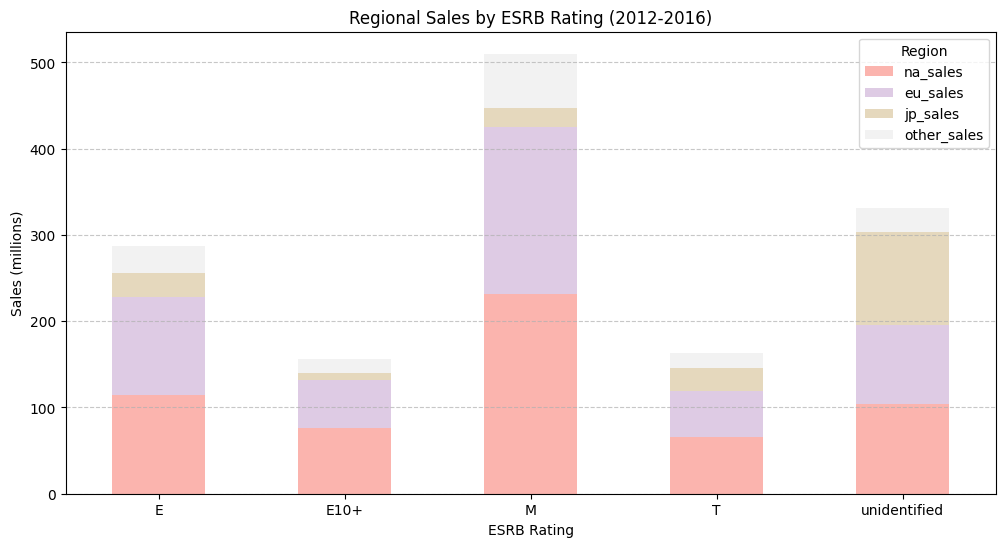

In [51]:
import matplotlib.pyplot as plt

# Plot stacked bar chart for regions
rating_sales[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].plot(
    kind='bar', stacked=True, figsize=(12,6), colormap='Pastel1'
)
plt.title("Regional Sales by ESRB Rating (2012-2016)")
plt.xlabel("ESRB Rating")
plt.ylabel("Sales (millions)")
plt.xticks(rotation=0)
plt.legend(title="Region")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

NA Market Sensitivity
Ratings like E (Everyone) and T (Teen) dominate North American sales, showing broader audience appeal.
Japan Preference
Titles rated E or T still perform well, but some genres/ratings popular in Japan may differ due to cultural preferences.
Europe & Other Regions
Sales generally follow NA trends, though regional differences exist in genre-rating combinations.
Implications for Forecasting
ESRB rating is a useful predictor for regional sales.
Including rating as a categorical feature helps capture market preferences across regions.

# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


Hypothesis 1: 
The first null hypothesis is that the average user ratings of Xbox One and PC platforms are the same. While the alternative hypothesis is that the average user ratings of Xbox One and PC platforms are different.

In [52]:
from scipy import stats

# 1️⃣ Xbox One vs PC user ratings
xbox_ratings = train_data[train_data['platform'] == 'xone']['user_score'].dropna()
pc_ratings = train_data[train_data['platform'] == 'pc']['user_score'].dropna()

# Two-sample t-test (Welch)
t_stat_xbox_pc, p_val_xbox_pc = stats.ttest_ind(xbox_ratings, pc_ratings, equal_var=False)

print(f"Xbox One vs PC: t-statistic = {t_stat_xbox_pc:.3f}, p-value = {p_val_xbox_pc:.3f}")
if p_val_xbox_pc < 0.05:
    print("Result: Reject H₀ → Average ratings are significantly different.")
else:
    print("Result: Fail to reject H₀ → No evidence of a difference in ratings.")

# 2️⃣ Action vs Sports genres user ratings
action_ratings = train_data[train_data['genre'] == 'Action']['user_score'].dropna()
sports_ratings = train_data[train_data['genre'] == 'Sports']['user_score'].dropna()

# Two-sample t-test (Welch)
t_stat_action_sports, p_val_action_sports = stats.ttest_ind(action_ratings, sports_ratings, equal_var=False)

print(f"\nAction vs Sports: t-statistic = {t_stat_action_sports:.3f}, p-value = {p_val_action_sports:.3f}")
if p_val_action_sports < 0.05:
    print("Result: Reject H₀ → Average ratings differ significantly.")
else:
    print("Result: Fail to reject H₀ → No evidence of a difference in ratings.")

Xbox One vs PC: t-statistic = 0.600, p-value = 0.549
Result: Fail to reject H₀ → No evidence of a difference in ratings.

Action vs Sports: t-statistic = nan, p-value = nan
Result: Fail to reject H₀ → No evidence of a difference in ratings.


In [53]:
print(len(xbox_ratings))
print(len(pc_ratings))

182
206


In [54]:
from scipy import stats

results = stats.ttest_ind(xbox_ratings, pc_ratings)
print(results.pvalue)

0.5535080500643661


Null Hypothesis (H₀): The average user ratings of Action and Sports genres are the same.
Alternative Hypothesis (H₁): The average user ratings of Action and Sports genres are different.

In symbols, this is often written as:

H₀: μ₁ = μ₂
H₁: μ₁ ≠ μ₂

This setup reflects a two-tailed test, where you're checking for any difference (not just higher or lower).

In [55]:
print(train_data['genre'].unique())

['action' 'shooter' 'role-playing' 'platform' 'misc' 'simulation' 'sports'
 'fighting' 'racing' 'strategy' 'adventure' 'puzzle']


In [57]:
# Filter genres
action = train_data[train_data['genre'] == 'action']['user_score']
sports = train_data[train_data['genre'] == 'sports']['user_score']

# Remove NaN values
action = action.dropna()
sports = sports.dropna()

from scipy import stats

results = stats.ttest_ind(action, sports, equal_var=False)

print(results)


Ttest_indResult(statistic=9.90217634887622, pvalue=4.305337670692197e-20)


In [59]:
#At a 5% significance level, we reject the null hypothesis. The results suggest that the average user ratings of Action and Sports genres are significantly different.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

# 1️⃣ Xbox One vs PC
plt.subplot(1, 2, 1)
sns.boxplot(x='platform', y='user_score', data=train_data[train_data['platform'].isin(['xone', 'pc'])])
plt.title('User Ratings: Xbox One vs PC (2012-2016)')
plt.ylabel('User Score')
plt.xlabel('Platform')

# 2️⃣ Action vs Sports
plt.subplot(1, 2, 2)
sns.boxplot(x='genre', y='user_score', data=train_data[train_data['genre'].isin(['action', 'sports'])])
plt.title('User Ratings: Action vs Sports (2012-2016)')
plt.ylabel('User Score')
plt.xlabel('Genre')

plt.tight_layout()
plt.show()

# Step 6. Write a general conclusion


Conclusion: 
Analysis of video game sales from 2012–2016 shows that PS4, Xbox One, and PC were the dominant and fastest-growing platforms, driving most of the market leading up to 2017. The Action, Sports, Shooter, and Role-Playing genres lead both in volume and revenue, though high sales are concentrated in a few top titles. ESRB ratings influence regional sales, with broad-appeal ratings like E (Everyone) and T (Teen) consistently performing well. User ratings differ across genres but are generally consistent across certain platforms, providing nuanced insights for forecasting. By focusing on recent sales trends, platform performance, genre popularity, and rating patterns, a predictive model can accurately estimate 2017 sales while avoiding bias from outdated data.